In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

# Dataset

In [2]:
df = pd.read_csv(
    '../outputs/predictions/staten_island_otp_features.csv'
)

df['Month'] = pd.to_datetime(df['Month'])

df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,...,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,Delayed_Trains_Lag_1,Scheduled_Trips_Lag_1,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP
0,2006-07-01,7-Day,104,3362,0.970,192,3274,0.945,3466,26.0,...,0.983,0.968,0.965,61.0,3490.0,0.972000,0.974833,97.666667,0.030006,0.971
1,2006-08-01,7-Day,105,3506,0.971,160,3451,0.956,3611,0.0,...,0.970,0.983,0.968,104.0,3466.0,0.973667,0.978333,92.666667,0.029078,0.953
2,2006-09-01,7-Day,159,3228,0.953,220,3167,0.935,3387,0.0,...,0.971,0.970,0.983,105.0,3611.0,0.974667,0.976167,90.000000,0.046944,0.955
3,2006-10-01,7-Day,159,3401,0.955,220,3340,0.938,3560,38.0,...,0.953,0.971,0.970,159.0,3387.0,0.964667,0.968333,122.666667,0.044663,0.930
4,2006-11-01,7-Day,239,3197,0.930,303,3133,0.912,3436,20.0,...,0.955,0.953,0.971,159.0,3560.0,0.959667,0.966667,141.000000,0.069558,0.980


# trained model

In [3]:
model = joblib.load(
    '../models/xgboost_otp_model.pkl'
)

# Encode dataset

In [4]:
df_encoded = pd.get_dummies(
    df,
    columns=['Day Time', 'Season'],
    drop_first=True
)

# Match training features

In [5]:
expected_cols = model.get_booster().feature_names

# Add missing columns

In [6]:
for col in expected_cols:
    if col not in df_encoded.columns:
        df_encoded[col] = 0

# Features

In [7]:
X_all = df_encoded[expected_cols]

# initial forecast base

In [8]:
latest_row = X_all.iloc[-1:].copy()

latest_row

,Delayed Trains,On-Time Trips,Scheduled Trips,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Lag_1,Delayed_Trains_Rolling_3,...,Year,Month_Number,Quarter,Day Time_AM Rush,Day Time_PM Rush,Day Time_Weekday,Day Time_Weekend,Season_Spring,Season_Summer,Season_Winter
1169,11,853,864,0.949,0.993,0.998,0.98,0.983333,54.0,20.333333,...,2025,12,4,False,False,False,True,False,False,True


# 
future predictions

In [9]:
future_predictions = []

# Recursive forecast loop

In [10]:
current_row = latest_row.copy()

for i in range(6):

    pred = model.predict(current_row)[0]

    future_predictions.append(pred)

    current_row['OTP_Lag_3'] = current_row['OTP_Lag_2']
    current_row['OTP_Lag_2'] = current_row['OTP_Lag_1']
    current_row['OTP_Lag_1'] = pred

    current_row['OTP_Rolling_3'] = (
        current_row[['OTP_Lag_1', 'OTP_Lag_2', 'OTP_Lag_3']]
        .mean(axis=1)
    )

# creating future dates

In [11]:
last_date = df['Month'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

# Forecast data frame

In [12]:
forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecasted_OTP': future_predictions
})

forecast_df

,Month,Forecasted_OTP
0,2026-01-01,0.978357
1,2026-02-01,0.979953
2,2026-03-01,0.975432
3,2026-04-01,0.973236
4,2026-05-01,0.969829
5,2026-06-01,0.973677


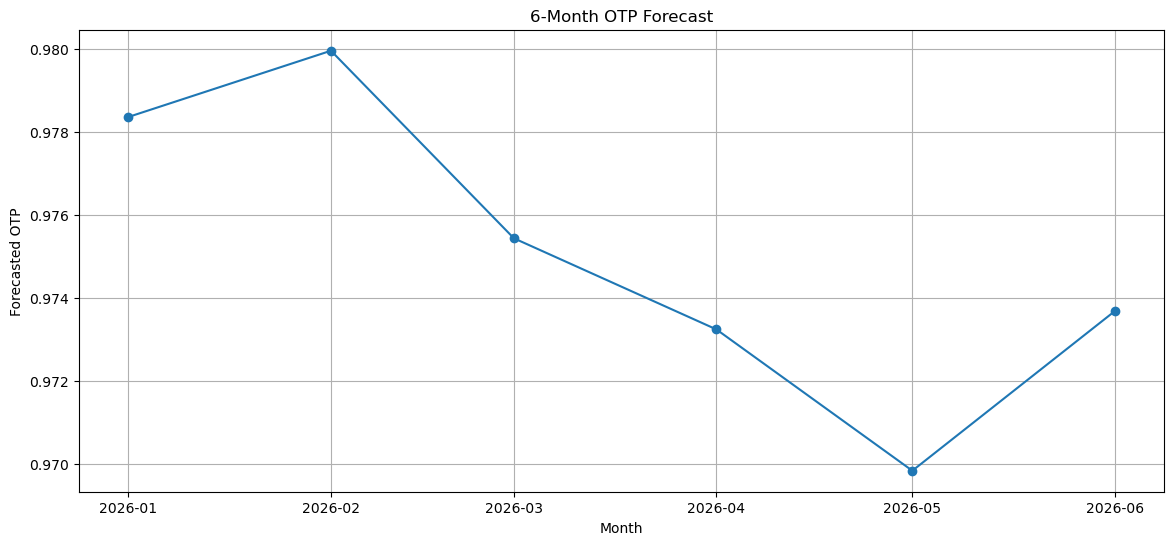

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df['Month'],
    forecast_df['Forecasted_OTP'],
    marker='o'
)

plt.title('6-Month OTP Forecast')

plt.xlabel('Month')
plt.ylabel('Forecasted OTP')

plt.grid(True)

plt.show()